###  Installation de l'environnement

In [1]:
#%pip install -r requirements.txt

In [2]:
%pip install plotly-express

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install nbformat

Note: you may need to restart the kernel to use updated packages.


### Connexion à la DB DuckDB

In [4]:
import duckdb
import os
from pathlib import Path
from typing import List
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from tqdm import tqdm
import sklearn
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import plotly.express as px
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

### Connexion à la DB / Import des Data


In [5]:
# Store database at project root
DB_NAME = Path("/home/c-enjalbert/Documents/Github/MSPR/bloc_2/amazing/amazing.duckdb") 
# Go up one level from current directory to get to project root
data_folder = Path("..") / "data"
# For absolute certainty, you could use the absolute path
# data_folder = Path("/home/c-enjalbert/Documents/EPSI/MSPR/bloc_2/amazing/data")
con = duckdb.connect(str(DB_NAME))

## Segmentation RFM 

In [6]:
%pip install pytest

Note: you may need to restart the kernel to use updated packages.


In [7]:
import duckdb
import os
from pathlib import Path
from typing import List
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

### Connexion à la DB / Import des Data


In [8]:
# Store database at project root
DB_NAME = Path("/home/c-enjalbert/Documents/Github/MSPR/bloc_2/amazing/amazing.duckdb") 
# Go up one level from current directory to get to project root
data_folder = Path("..") / "data"
# For absolute certainty, you could use the absolute path
# data_folder = Path("/home/c-enjalbert/Documents/EPSI/MSPR/bloc_2/amazing/data")
con = duckdb.connect(str(DB_NAME))

In [9]:
# 2. Query to list all tables in the database
# DuckDB specific way to list tables
tables_info = con.sql("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'main'
    ORDER BY table_name
""").df()

print(f"Found {len(tables_info)} tables in the database:\n")

if len(tables_info) > 0:
    for i, table_name in enumerate(tables_info['table_name']):
        print(f"{i+1}. {table_name}")
else:
    print("No tables found in the database.")

Found 4 tables in the database:

1. all_events
2. loaded_files
3. user_events
4. user_segments_kmeans


In [10]:
# 5. Alternative way to show all tables
print("List of all tables using DuckDB's connections.tables():")
con.sql("SHOW TABLES").show()

List of all tables using DuckDB's connections.tables():
┌──────────────────────┐
│         name         │
│       varchar        │
├──────────────────────┤
│ all_events           │
│ loaded_files         │
│ user_events          │
│ user_segments_kmeans │
└──────────────────────┘



In [11]:
# Show count of records in user_segments
user_segments_data = con.sql("""
    SELECT *
    FROM user_events
    ORDER BY RANDOM()
    LIMIT 10000
""")
user_segments_data.show()

# Examine the loaded_files table
print("\nContents of loaded_files table:")
loaded_files_data = con.sql("""
    SELECT * FROM loaded_files
""")
loaded_files_data.show()


┌───────────┬──────────────┬─────────────┬─────────────────┬─────────────────────────┬────────────────────┬────────────────────┬─────────────────────┬──────────────────────┬──────────────────────┬───────────────────────┐
│  user_id  │ total_events │ total_views │ total_purchases │ avg_time_between_events │    total_spent     │     avg_basket     │   last_event_time   │   conversion_rate    │    purchase_ratio    │ days_since_last_event │
│  varchar  │    int64     │   double    │     double      │         double          │       double       │       double       │      timestamp      │        double        │        double        │         int64         │
├───────────┼──────────────┼─────────────┼─────────────────┼─────────────────────────┼────────────────────┼────────────────────┼─────────────────────┼──────────────────────┼──────────────────────┼───────────────────────┤
│ 623327690 │           18 │        18.0 │             0.0 │      172887.88235294117 │                0.0 │         

In [12]:
user_segments_df_tmspt = user_segments_data.df()

In [13]:
user_segments_df = user_segments_data.df()

In [14]:
user_segments_df_tmspt.columns

Index(['user_id', 'total_events', 'total_views', 'total_purchases',
       'avg_time_between_events', 'total_spent', 'avg_basket',
       'last_event_time', 'conversion_rate', 'purchase_ratio',
       'days_since_last_event'],
      dtype='object')

In [15]:
# Check basic statistics and missing values
print("Basic statistics of the dataset:")
print(f"Number of users: {len(user_segments_df_tmspt)}")
print(f"Number of columns: {len(user_segments_df_tmspt.columns)}")
print("\nMissing values per column:")
print(user_segments_df_tmspt.isna().sum())

# Generate descriptive statistics
print("\nDescriptive statistics:")
user_segments_df_tmspt_stats = user_segments_df_tmspt.describe()
user_segments_df_tmspt_stats

Basic statistics of the dataset:
Number of users: 10000
Number of columns: 11

Missing values per column:
user_id                    0
total_events               0
total_views                0
total_purchases            0
avg_time_between_events    0
total_spent                0
avg_basket                 0
last_event_time            0
conversion_rate            0
purchase_ratio             0
days_since_last_event      0
dtype: int64

Descriptive statistics:


,total_events,total_views,total_purchases,avg_time_between_events,total_spent,avg_basket,last_event_time,conversion_rate,purchase_ratio,days_since_last_event
count,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000,10000.000000,10000.000000,10000.000000
mean,69.270400,64.762200,1.215300,2.130557e+05,355.484579,82.478404,2020-02-29 19:31:53.819500,0.026752,0.022233,31.070800
min,10.000000,0.000000,0.000000,1.428571e-01,0.000000,0.000000,2019-10-01 04:43:04,0.000000,0.000000,-30.000000
25%,16.000000,15.000000,0.000000,3.352098e+04,0.000000,0.000000,2020-01-21 03:08:39,0.000000,0.000000,-19.000000
50%,31.000000,28.000000,0.000000,1.142641e+05,0.000000,0.000000,2020-03-14 03:57:42,0.000000,0.000000,17.000000
75%,71.000000,66.000000,1.000000,2.810585e+05,110.692500,71.962500,2020-04-20 16:57:40,0.015250,0.015021,70.000000
max,3832.000000,3497.000000,164.000000,1.977069e+06,74265.630000,2562.720000,2020-04-30 23:59:51,1.000000,0.500000,182.000000
std,134.194994,128.157479,4.995322,2.703445e+05,1879.449231,198.009438,NaN,0.073560,0.054079,56.589291


In [16]:
user_segments_df_tmspt_stats["avg_time_between_events"]

count    1.000000e+04
mean     2.130557e+05
min      1.428571e-01
25%      3.352098e+04
50%      1.142641e+05
75%      2.810585e+05
max      1.977069e+06
std      2.703445e+05
Name: avg_time_between_events, dtype: float64

In [17]:
user_segments_df_tmspt_stats["days_since_last_event"]

count    10000.000000
mean        31.070800
min        -30.000000
25%        -19.000000
50%         17.000000
75%         70.000000
max        182.000000
std         56.589291
Name: days_since_last_event, dtype: float64

In [18]:
user_segments_df_tmspt['days_since_last_event']

0       -27
1        55
2        75
3        96
4       117
       ... 
9995    -29
9996    -29
9997    127
9998      4
9999     25
Name: days_since_last_event, Length: 10000, dtype: int64

In [19]:
user_segments_df_tmspt

,user_id,total_events,total_views,total_purchases,avg_time_between_events,total_spent,avg_basket,last_event_time,conversion_rate,purchase_ratio,days_since_last_event
0,621163423,60,54.0,2.0,78251.813559,669.20,334.60,2020-04-28 02:49:41,0.037037,0.035714,-27
1,536363804,13,13.0,0.0,888128.250000,0.00,0.00,2020-02-05 10:43:55,0.000000,0.000000,55
2,601653033,10,10.0,0.0,5440.111111,0.00,0.00,2020-01-16 10:05:39,0.000000,0.000000,75
3,591083299,12,10.0,1.0,24846.545455,137.96,137.96,2019-12-26 08:02:20,0.100000,0.090909,96
4,567691716,10,10.0,0.0,287666.000000,0.00,0.00,2019-12-05 04:59:30,0.000000,0.000000,117
...,...,...,...,...,...,...,...,...,...,...,...
9995,623201708,160,143.0,6.0,31661.735849,666.06,111.01,2020-04-30 17:48:55,0.041958,0.040268,-29
9996,516410428,30,26.0,1.0,567358.551724,30.81,30.81,2020-04-30 14:36:50,0.038462,0.037037,-29
9997,576519422,31,29.0,1.0,135.366667,133.83,133.83,2019-11-25 14:35:50,0.034483,0.033333,127
9998,602935972,173,173.0,0.0,34519.906977,0.00,0.00,2020-03-27 11:10:33,0.000000,0.000000,4


In [20]:
print(user_segments_df_tmspt['last_event_time'].iloc[0:5])
print(type(user_segments_df_tmspt['last_event_time'].iloc[0]))

0   2020-04-28 02:49:41
1   2020-02-05 10:43:55
2   2020-01-16 10:05:39
3   2019-12-26 08:02:20
4   2019-12-05 04:59:30
Name: last_event_time, dtype: datetime64[us]
<class 'pandas._libs.tslibs.timestamps.Timestamp'>


In [21]:
# Conversion des jours en mois (approximation: 30 jours = 1 mois)
user_segments_df_tmspt['months_since_last_event'] = user_segments_df_tmspt['days_since_last_event'] / 30

In [22]:
def perform_rfm_analysis(df, 
                        r_column='months_since_last_event',
                        r_thresholds=[1, 5],
                        r_scores=[2, 1, 0],
                        f_column='total_purchases',
                        f_thresholds=[2, 10],
                        f_scores=[0, 1, 2],
                        m_column='total_spent',
                        m_thresholds=[20, 50],
                        m_scores=[0, 1, 2],
                        segment_thresholds=[0, 2, 3, 4, 6],
                        segment_names=['Clients Perdus', 'Clients à Risque', 'Clients Potentiels', 'Clients Fidèles', 'Champions'],
                        days_to_months=30,
                        visualize=True):
    """
    Réalise une analyse RFM complète avec des seuils et critères personnalisables
    
    Args:
        df (pd.DataFrame): DataFrame contenant les données client
        r_column (str): Nom de la colonne pour la récence
        r_thresholds (list): Seuils pour la récence (ex: [1, 5] pour <1 mois, 1-5 mois, >5 mois)
        r_scores (list): Scores à attribuer pour chaque segment de récence
        f_column (str): Nom de la colonne pour la fréquence
        f_thresholds (list): Seuils pour la fréquence (ex: [2, 10] pour <2, 2-10, >10)
        f_scores (list): Scores à attribuer pour chaque segment de fréquence
        m_column (str): Nom de la colonne pour le montant
        m_thresholds (list): Seuils pour le montant (ex: [20, 50] pour <20€, 20-50€, >50€)
        m_scores (list): Scores à attribuer pour chaque segment de montant
        segment_thresholds (list): Seuils pour les segments client basés sur le score RFM total
        segment_names (list): Noms des segments clients
        days_to_months (int): Facteur de conversion jours en mois (si applicable)
        visualize (bool): Afficher les graphiques
    
    Returns:
        pd.DataFrame: DataFrame original avec les scores et segments RFM ajoutés
    """
    # Créer une copie du dataframe pour ne pas modifier l'original
    df_rfm = df.copy()
    
    # Convertir days_since_last_event en months_since_last_event si nécessaire
    if r_column == 'months_since_last_event' and 'days_since_last_event' in df_rfm.columns and 'months_since_last_event' not in df_rfm.columns:
        df_rfm['months_since_last_event'] = df_rfm['days_since_last_event'] / days_to_months
    
    # Fonction pour assigner les scores selon les critères et seuils
    def assign_score(value, thresholds, scores):
        if len(thresholds) + 1 != len(scores):
            raise ValueError("Le nombre de scores doit être égal au nombre de seuils + 1")
        
        # Vérifier dans quelle plage se trouve la valeur
        for i, threshold in enumerate(thresholds):
            if value < threshold:
                return scores[i]
        
        # Si la valeur est supérieure à tous les seuils, retourner le dernier score
        return scores[-1]
    
    # Appliquer les fonctions de score
    df_rfm['R_score'] = df_rfm[r_column].apply(lambda x: assign_score(x, r_thresholds, r_scores))
    df_rfm['F_score'] = df_rfm[f_column].apply(lambda x: assign_score(x, f_thresholds, f_scores))
    df_rfm['M_score'] = df_rfm[m_column].apply(lambda x: assign_score(x, m_thresholds, m_scores))
    
    # Créer un score RFM combiné (comme une chaîne de caractères)
    df_rfm['RFM_segment'] = df_rfm['R_score'].astype(str) + \
                           df_rfm['F_score'].astype(str) + \
                           df_rfm['M_score'].astype(str)
    
    # Calculer le score RFM total
    df_rfm['RFM_score'] = df_rfm['R_score'] + df_rfm['F_score'] + df_rfm['M_score']
    
    # Fonction pour attribuer un segment en fonction du score RFM total
    def assign_segment(score, thresholds, names):
        if len(thresholds) != len(names):
            raise ValueError("Le nombre de noms de segments doit être égal au nombre de seuils")
            
        for i in range(len(thresholds)-1):
            if thresholds[i] <= score < thresholds[i+1]:
                return names[i]
                
        return names[-1]  # Dernier segment si score >= dernier seuil
    
    # Attribuer les segments
    df_rfm['segment'] = df_rfm['RFM_score'].apply(lambda x: assign_segment(x, segment_thresholds, segment_names))
    
    # Afficher les résultats
    print("RFM Analysis Completed")
    print(f"Total clients segmentés: {len(df_rfm)}")
    
    # Afficher la distribution des scores individuels
    print("\nDistribution des scores R:")
    r_dist = df_rfm['R_score'].value_counts().sort_index()
    print(r_dist)
    
    print("\nDistribution des scores F:")
    f_dist = df_rfm['F_score'].value_counts().sort_index()
    print(f_dist)
    
    print("\nDistribution des scores M:")
    m_dist = df_rfm['M_score'].value_counts().sort_index()
    print(m_dist)
    
    print("\nDistribution des segments RFM:")
    print(df_rfm['RFM_segment'].value_counts())
    
    # Afficher les critères RFM utilisés
    print("\n--- CRITÈRES RFM UTILISÉS ---\n")
    
    # Récence
    print(f"RÉCENCE ({r_column}):")
    if len(r_thresholds) == 2:
        print(f"Score {r_scores[0]}: moins de {r_thresholds[0]}")
        print(f"Score {r_scores[1]}: entre {r_thresholds[0]} et {r_thresholds[1]}")
        print(f"Score {r_scores[2]}: plus de {r_thresholds[1]}")
    else:
        for i in range(len(r_scores)):
            if i == 0:
                print(f"Score {r_scores[i]}: moins de {r_thresholds[i]}")
            elif i == len(r_scores) - 1:
                print(f"Score {r_scores[i]}: plus de {r_thresholds[i-1]}")
            else:
                print(f"Score {r_scores[i]}: entre {r_thresholds[i-1]} et {r_thresholds[i]}")
    
    # Fréquence
    print(f"\nFRÉQUENCE ({f_column}):")
    if len(f_thresholds) == 2:
        print(f"Score {f_scores[0]}: moins de {f_thresholds[0]}")
        print(f"Score {f_scores[1]}: entre {f_thresholds[0]} et {f_thresholds[1]}")
        print(f"Score {f_scores[2]}: plus de {f_thresholds[1]}")
    else:
        for i in range(len(f_scores)):
            if i == 0:
                print(f"Score {f_scores[i]}: moins de {f_thresholds[i]}")
            elif i == len(f_scores) - 1:
                print(f"Score {f_scores[i]}: plus de {f_thresholds[i-1]}")
            else:
                print(f"Score {f_scores[i]}: entre {f_thresholds[i-1]} et {f_thresholds[i]}")
    
    # Montant
    print(f"\nMONTANT ({m_column}):")
    if len(m_thresholds) == 2:
        print(f"Score {m_scores[0]}: moins de {m_thresholds[0]}€")
        print(f"Score {m_scores[1]}: entre {m_thresholds[0]}€ et {m_thresholds[1]}€")
        print(f"Score {m_scores[2]}: plus de {m_thresholds[1]}€")
    else:
        for i in range(len(m_scores)):
            if i == 0:
                print(f"Score {m_scores[i]}: moins de {m_thresholds[i]}€")
            elif i == len(m_scores) - 1:
                print(f"Score {m_scores[i]}: plus de {m_thresholds[i-1]}€")
            else:
                print(f"Score {m_scores[i]}: entre {m_thresholds[i-1]}€ et {m_thresholds[i]}€")
    
    # Distribution des segments de clients
    print("\nDistribution des segments de clients:")
    segment_counts = df_rfm['segment'].value_counts()
    for segment, count in segment_counts.items():
        print(f"{segment}: {count} clients ({count/len(df_rfm)*100:.1f}%)")
    
    # Visualisation
    if visualize:
        # Visualisation des segments
        plt.figure(figsize=(10, 6))
        sns.countplot(x='segment', data=df_rfm, order=segment_counts.index)
        plt.title('Distribution des Segments Clients')
        plt.xlabel('Segment')
        plt.ylabel('Nombre de Clients')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
        # Visualisation des scores R, F, M
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        sns.countplot(x='R_score', data=df_rfm, ax=axes[0])
        axes[0].set_title('Distribution des Scores R')
        axes[0].set_xlabel('Score R')
        axes[0].set_ylabel('Nombre de Clients')
        
        sns.countplot(x='F_score', data=df_rfm, ax=axes[1])
        axes[1].set_title('Distribution des Scores F')
        axes[1].set_xlabel('Score F')
        axes[1].set_ylabel('Nombre de Clients')
        
        sns.countplot(x='M_score', data=df_rfm, ax=axes[2])
        axes[2].set_title('Distribution des Scores M')
        axes[2].set_xlabel('Score M')
        axes[2].set_ylabel('Nombre de Clients')
        
        plt.tight_layout()
        plt.show()
    
    # Générer un tableau récapitulatif avec les caractéristiques de chaque segment
    print("\nCaractéristiques moyennes par segment:")
    segment_stats = df_rfm.groupby('segment').agg({
        r_column: 'mean',
        f_column: 'mean',
        m_column: 'mean',
        'R_score': 'mean',
        'F_score': 'mean',
        'M_score': 'mean',
        'RFM_score': 'mean',
        df_rfm.columns[0]: 'count'  # Utiliser la première colonne pour le comptage
    }).rename(columns={df_rfm.columns[0]: 'count'}).sort_values(by='RFM_score', ascending=False)
    
    segment_stats = segment_stats.round(2)
    display(segment_stats)
    
    return df_rfm



RFM Analysis Completed
Total clients segmentés: 10000

Distribution des scores R:
R_score
0     371
1    3734
2    5895
Name: count, dtype: int64

Distribution des scores F:
F_score
0    8152
1    1626
2     222
Name: count, dtype: int64

Distribution des scores M:
M_score
0    6941
1     222
2    2837
Name: count, dtype: int64

Distribution des segments RFM:
RFM_segment
200    3995
100    2680
212    1007
202     583
112     532
102     389
000     260
222     156
201     126
101      67
122      62
012      55
002      49
211      22
210       6
111       4
022       4
001       3
Name: count, dtype: int64

--- CRITÈRES RFM UTILISÉS ---

RÉCENCE (months_since_last_event):
Score 2: moins de 1
Score 1: entre 1 et 5
Score 0: plus de 5

FRÉQUENCE (total_purchases):
Score 0: moins de 2
Score 1: entre 2 et 10
Score 2: plus de 10

MONTANT (total_spent):
Score 0: moins de 20€
Score 1: entre 20€ et 50€
Score 2: plus de 50€

Distribution des segments de clients:
Clients Perdus: 7054 clients (7

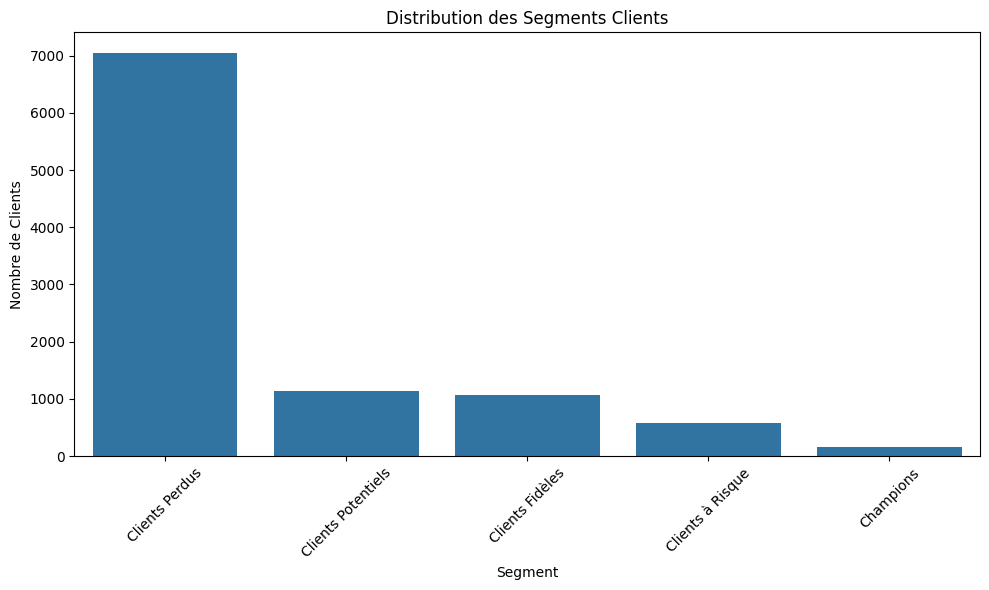

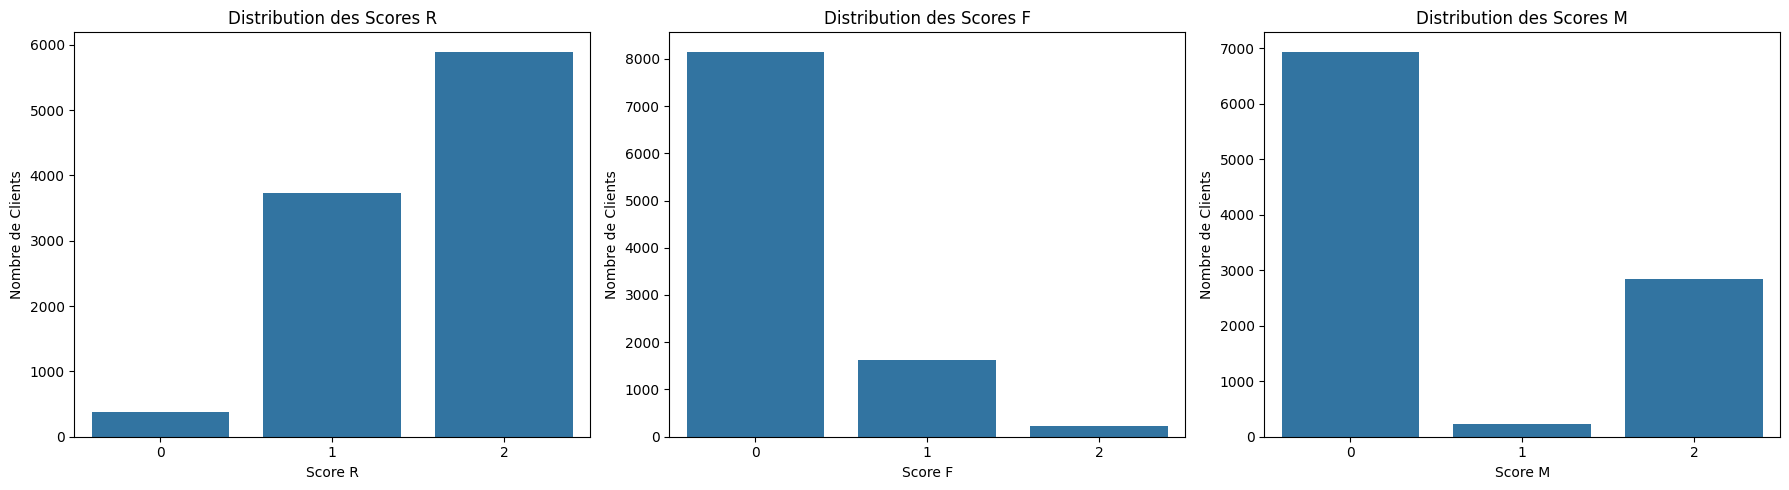


Caractéristiques moyennes par segment:


,months_since_last_event,total_purchases,total_spent,R_score,F_score,M_score,RFM_score,count
segment,,,,,,,,
Champions,-0.32,23.51,7222.19,2.00,2.00,2.00,6.00,156
Clients Fidèles,-0.21,4.71,1390.53,1.94,1.06,2.00,5.00,1069
Clients Potentiels,1.11,2.21,656.08,1.53,0.49,1.98,4.00,1141
Clients à Risque,2.33,1.24,302.81,1.13,0.11,1.76,3.00,580
Clients Perdus,1.14,0.03,2.48,1.52,0.00,0.02,1.55,7054


"\nrfm_custom = perform_rfm_analysis(\n    user_segments_df,\n    r_column='months_since_last_event',\n    r_thresholds=[0.5, 2, 6],  # 4 segments de récence\n    r_scores=[3, 2, 1, 0],\n    f_column='total_purchases',\n    f_thresholds=[1, 5, 15],  # 4 segments de fréquence\n    f_scores=[0, 1, 2, 3],\n    m_column='total_spent',\n    m_thresholds=[10, 30, 80],  # 4 segments de montant\n    m_scores=[0, 1, 2, 3],\n    segment_thresholds=[0, 2, 4, 6, 8],  # Seuils de segmentation personnalisés\n    segment_names=['Inactifs', 'À Réactiver', 'Réguliers', 'Fidèles', 'VIP']\n)\n"

In [23]:

user_segments_complete = perform_rfm_analysis(
    user_segments_df_tmspt,
    r_column='months_since_last_event',
    r_thresholds=[1, 5],
    r_scores=[2, 1, 0],
    f_column='total_purchases',
    f_thresholds=[2, 10],
    f_scores=[0, 1, 2],
    m_column='total_spent',
    m_thresholds=[20, 50],
    m_scores=[0, 1, 2],
    segment_thresholds=[0, 3, 4, 5, 6],
    segment_names=['Clients Perdus', 'Clients à Risque', 'Clients Potentiels', 'Clients Fidèles', 'Champions']
)

# Pour utiliser avec un autre jeu de critères, il suffit d'appeler la fonction 
# avec des paramètres différents, par exemple:
"""
rfm_custom = perform_rfm_analysis(
    user_segments_df,
    r_column='months_since_last_event',
    r_thresholds=[0.5, 2, 6],  # 4 segments de récence
    r_scores=[3, 2, 1, 0],
    f_column='total_purchases',
    f_thresholds=[1, 5, 15],  # 4 segments de fréquence
    f_scores=[0, 1, 2, 3],
    m_column='total_spent',
    m_thresholds=[10, 30, 80],  # 4 segments de montant
    m_scores=[0, 1, 2, 3],
    segment_thresholds=[0, 2, 4, 6, 8],  # Seuils de segmentation personnalisés
    segment_names=['Inactifs', 'À Réactiver', 'Réguliers', 'Fidèles', 'VIP']
)
"""

In [24]:
user_segments_complete

,user_id,total_events,total_views,total_purchases,avg_time_between_events,total_spent,avg_basket,last_event_time,conversion_rate,purchase_ratio,days_since_last_event,months_since_last_event,R_score,F_score,M_score,RFM_segment,RFM_score,segment
0,621163423,60,54.0,2.0,78251.813559,669.20,334.60,2020-04-28 02:49:41,0.037037,0.035714,-27,-0.900000,2,1,2,212,5,Clients Fidèles
1,536363804,13,13.0,0.0,888128.250000,0.00,0.00,2020-02-05 10:43:55,0.000000,0.000000,55,1.833333,1,0,0,100,1,Clients Perdus
2,601653033,10,10.0,0.0,5440.111111,0.00,0.00,2020-01-16 10:05:39,0.000000,0.000000,75,2.500000,1,0,0,100,1,Clients Perdus
3,591083299,12,10.0,1.0,24846.545455,137.96,137.96,2019-12-26 08:02:20,0.100000,0.090909,96,3.200000,1,0,2,102,3,Clients à Risque
4,567691716,10,10.0,0.0,287666.000000,0.00,0.00,2019-12-05 04:59:30,0.000000,0.000000,117,3.900000,1,0,0,100,1,Clients Perdus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,623201708,160,143.0,6.0,31661.735849,666.06,111.01,2020-04-30 17:48:55,0.041958,0.040268,-29,-0.966667,2,1,2,212,5,Clients Fidèles
9996,516410428,30,26.0,1.0,567358.551724,30.81,30.81,2020-04-30 14:36:50,0.038462,0.037037,-29,-0.966667,2,0,1,201,3,Clients à Risque
9997,576519422,31,29.0,1.0,135.366667,133.83,133.83,2019-11-25 14:35:50,0.034483,0.033333,127,4.233333,1,0,2,102,3,Clients à Risque
9998,602935972,173,173.0,0.0,34519.906977,0.00,0.00,2020-03-27 11:10:33,0.000000,0.000000,4,0.133333,2,0,0,200,2,Clients Perdus


In [25]:
# Analyse des paniers moyens (avg_basket)
print("\n--- ANALYSE DES PANIERS MOYENS ---")

# Compter les paniers avec avg_basket = 0
zero_baskets = len(user_segments_complete[user_segments_complete['avg_basket'] == 0])
print(f"Nombre de clients avec panier moyen = 0: {zero_baskets} ({zero_baskets/len(user_segments_complete)*100:.1f}%)")

# Compter les paniers avec avg_basket > 0
non_zero_baskets = len(user_segments_complete[user_segments_complete['avg_basket'] > 0])
print(f"Nombre de clients avec panier moyen > 0: {non_zero_baskets} ({non_zero_baskets/len(user_segments_complete)*100:.1f}%)")




--- ANALYSE DES PANIERS MOYENS ---
Nombre de clients avec panier moyen = 0: 6843 (68.4%)
Nombre de clients avec panier moyen > 0: 3157 (31.6%)


In [26]:
# Analyse de la récence (months_since_last_event)
print("\n--- Analyse de months_since_last_event ---")

moins_1_mois = len(user_segments_complete[user_segments_complete['months_since_last_event'] < 1])
entre_1_5_mois = len(user_segments_complete[(user_segments_complete['months_since_last_event'] >= 1) & (user_segments_complete['months_since_last_event'] <= 5)])
plus_5_mois = len(user_segments_complete[user_segments_complete['months_since_last_event'] > 5])

total = len(user_segments_complete)
print(f"Moins de 1 mois depuis le dernier événement : {moins_1_mois} ({moins_1_mois/total*100:.1f}%)")
print(f"Entre 1 et 5 mois depuis le dernier événement : {entre_1_5_mois} ({entre_1_5_mois/total*100:.1f}%)")
print(f"Plus de 5 mois depuis le dernier événement : {plus_5_mois} ({plus_5_mois/total*100:.1f}%)")




--- Analyse de months_since_last_event ---
Moins de 1 mois depuis le dernier événement : 5895 (59.0%)
Entre 1 et 5 mois depuis le dernier événement : 3746 (37.5%)
Plus de 5 mois depuis le dernier événement : 359 (3.6%)


In [27]:
user_segments_df

,user_id,total_events,total_views,total_purchases,avg_time_between_events,total_spent,avg_basket,last_event_time,conversion_rate,purchase_ratio,days_since_last_event
0,541446944,313,303.0,2.0,57360.028846,183.24,91.62,2020-04-28 18:24:26,0.006601,0.006557,-27
1,572640268,71,70.0,0.0,167896.242857,0.00,0.00,2020-04-01 16:35:23,0.000000,0.000000,0
2,512561655,28,28.0,0.0,404275.185185,0.00,0.00,2020-02-12 09:17:22,0.000000,0.000000,48
3,577142084,55,49.0,0.0,174586.444444,0.00,0.00,2020-03-14 17:41:05,0.000000,0.000000,17
4,586240664,22,21.0,0.0,235272.714286,0.00,0.00,2020-03-15 17:50:15,0.000000,0.000000,16
...,...,...,...,...,...,...,...,...,...,...,...
9995,536343907,57,56.0,0.0,306746.392857,0.00,0.00,2020-04-29 03:47:06,0.000000,0.000000,-28
9996,521787534,22,22.0,0.0,575843.476190,0.00,0.00,2020-03-19 14:03:29,0.000000,0.000000,12
9997,580662914,17,15.0,0.0,521499.937500,0.00,0.00,2020-03-07 19:55:33,0.000000,0.000000,24
9998,541116161,27,27.0,0.0,206881.653846,0.00,0.00,2020-02-26 08:52:03,0.000000,0.000000,34


In [28]:
user_segments_complete

,user_id,total_events,total_views,total_purchases,avg_time_between_events,total_spent,avg_basket,last_event_time,conversion_rate,purchase_ratio,days_since_last_event,months_since_last_event,R_score,F_score,M_score,RFM_segment,RFM_score,segment
0,621163423,60,54.0,2.0,78251.813559,669.20,334.60,2020-04-28 02:49:41,0.037037,0.035714,-27,-0.900000,2,1,2,212,5,Clients Fidèles
1,536363804,13,13.0,0.0,888128.250000,0.00,0.00,2020-02-05 10:43:55,0.000000,0.000000,55,1.833333,1,0,0,100,1,Clients Perdus
2,601653033,10,10.0,0.0,5440.111111,0.00,0.00,2020-01-16 10:05:39,0.000000,0.000000,75,2.500000,1,0,0,100,1,Clients Perdus
3,591083299,12,10.0,1.0,24846.545455,137.96,137.96,2019-12-26 08:02:20,0.100000,0.090909,96,3.200000,1,0,2,102,3,Clients à Risque
4,567691716,10,10.0,0.0,287666.000000,0.00,0.00,2019-12-05 04:59:30,0.000000,0.000000,117,3.900000,1,0,0,100,1,Clients Perdus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,623201708,160,143.0,6.0,31661.735849,666.06,111.01,2020-04-30 17:48:55,0.041958,0.040268,-29,-0.966667,2,1,2,212,5,Clients Fidèles
9996,516410428,30,26.0,1.0,567358.551724,30.81,30.81,2020-04-30 14:36:50,0.038462,0.037037,-29,-0.966667,2,0,1,201,3,Clients à Risque
9997,576519422,31,29.0,1.0,135.366667,133.83,133.83,2019-11-25 14:35:50,0.034483,0.033333,127,4.233333,1,0,2,102,3,Clients à Risque
9998,602935972,173,173.0,0.0,34519.906977,0.00,0.00,2020-03-27 11:10:33,0.000000,0.000000,4,0.133333,2,0,0,200,2,Clients Perdus


### Normalisation et Standardisation des données

In [29]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Sélectionner les features numériques
numeric_features = user_segments_df.drop(columns=["last_event_time"])

## Option 1: Standardisation (Z-score normalization) - moyenne=0, écart-type=1
#print("Standardisation des données...")
#std_scaler = StandardScaler()
#X_standardized = std_scaler.fit_transform(numeric_features)
#print(f"Shape après standardisation: {X_standardized.shape}")
#print(f"Moyenne après standardisation: {X_standardized.mean(axis=0)[:3]}...")  # ~0
#print(f"Écart-type après standardisation: {X_standardized.std(axis=0)[:3]}...")  # ~1


X_num_scaled = numeric_features



In [30]:
X_num_scaled.shape

(10000, 10)

In [31]:
X_num_scaled

,user_id,total_events,total_views,total_purchases,avg_time_between_events,total_spent,avg_basket,conversion_rate,purchase_ratio,days_since_last_event
0,541446944,313,303.0,2.0,57360.028846,183.24,91.62,0.006601,0.006557,-27
1,572640268,71,70.0,0.0,167896.242857,0.00,0.00,0.000000,0.000000,0
2,512561655,28,28.0,0.0,404275.185185,0.00,0.00,0.000000,0.000000,48
3,577142084,55,49.0,0.0,174586.444444,0.00,0.00,0.000000,0.000000,17
4,586240664,22,21.0,0.0,235272.714286,0.00,0.00,0.000000,0.000000,16
...,...,...,...,...,...,...,...,...,...,...
9995,536343907,57,56.0,0.0,306746.392857,0.00,0.00,0.000000,0.000000,-28
9996,521787534,22,22.0,0.0,575843.476190,0.00,0.00,0.000000,0.000000,12
9997,580662914,17,15.0,0.0,521499.937500,0.00,0.00,0.000000,0.000000,24
9998,541116161,27,27.0,0.0,206881.653846,0.00,0.00,0.000000,0.000000,34


In [32]:
# Replace for Using category embeddings
#X_final = np.hstack([X_num_scaled, X_emb_scaled])
X_final = X_num_scaled

In [33]:
X_final

,user_id,total_events,total_views,total_purchases,avg_time_between_events,total_spent,avg_basket,conversion_rate,purchase_ratio,days_since_last_event
0,541446944,313,303.0,2.0,57360.028846,183.24,91.62,0.006601,0.006557,-27
1,572640268,71,70.0,0.0,167896.242857,0.00,0.00,0.000000,0.000000,0
2,512561655,28,28.0,0.0,404275.185185,0.00,0.00,0.000000,0.000000,48
3,577142084,55,49.0,0.0,174586.444444,0.00,0.00,0.000000,0.000000,17
4,586240664,22,21.0,0.0,235272.714286,0.00,0.00,0.000000,0.000000,16
...,...,...,...,...,...,...,...,...,...,...
9995,536343907,57,56.0,0.0,306746.392857,0.00,0.00,0.000000,0.000000,-28
9996,521787534,22,22.0,0.0,575843.476190,0.00,0.00,0.000000,0.000000,12
9997,580662914,17,15.0,0.0,521499.937500,0.00,0.00,0.000000,0.000000,24
9998,541116161,27,27.0,0.0,206881.653846,0.00,0.00,0.000000,0.000000,34


In [34]:
X = user_segments_df.drop(columns=["last_event_time"])
X_rfm = user_segments_complete.drop(columns=["segment", "last_event_time", "RFM_segment"])

In [35]:
user_segments_df

,user_id,total_events,total_views,total_purchases,avg_time_between_events,total_spent,avg_basket,last_event_time,conversion_rate,purchase_ratio,days_since_last_event
0,541446944,313,303.0,2.0,57360.028846,183.24,91.62,2020-04-28 18:24:26,0.006601,0.006557,-27
1,572640268,71,70.0,0.0,167896.242857,0.00,0.00,2020-04-01 16:35:23,0.000000,0.000000,0
2,512561655,28,28.0,0.0,404275.185185,0.00,0.00,2020-02-12 09:17:22,0.000000,0.000000,48
3,577142084,55,49.0,0.0,174586.444444,0.00,0.00,2020-03-14 17:41:05,0.000000,0.000000,17
4,586240664,22,21.0,0.0,235272.714286,0.00,0.00,2020-03-15 17:50:15,0.000000,0.000000,16
...,...,...,...,...,...,...,...,...,...,...,...
9995,536343907,57,56.0,0.0,306746.392857,0.00,0.00,2020-04-29 03:47:06,0.000000,0.000000,-28
9996,521787534,22,22.0,0.0,575843.476190,0.00,0.00,2020-03-19 14:03:29,0.000000,0.000000,12
9997,580662914,17,15.0,0.0,521499.937500,0.00,0.00,2020-03-07 19:55:33,0.000000,0.000000,24
9998,541116161,27,27.0,0.0,206881.653846,0.00,0.00,2020-02-26 08:52:03,0.000000,0.000000,34


In [36]:
X

,user_id,total_events,total_views,total_purchases,avg_time_between_events,total_spent,avg_basket,conversion_rate,purchase_ratio,days_since_last_event
0,541446944,313,303.0,2.0,57360.028846,183.24,91.62,0.006601,0.006557,-27
1,572640268,71,70.0,0.0,167896.242857,0.00,0.00,0.000000,0.000000,0
2,512561655,28,28.0,0.0,404275.185185,0.00,0.00,0.000000,0.000000,48
3,577142084,55,49.0,0.0,174586.444444,0.00,0.00,0.000000,0.000000,17
4,586240664,22,21.0,0.0,235272.714286,0.00,0.00,0.000000,0.000000,16
...,...,...,...,...,...,...,...,...,...,...
9995,536343907,57,56.0,0.0,306746.392857,0.00,0.00,0.000000,0.000000,-28
9996,521787534,22,22.0,0.0,575843.476190,0.00,0.00,0.000000,0.000000,12
9997,580662914,17,15.0,0.0,521499.937500,0.00,0.00,0.000000,0.000000,24
9998,541116161,27,27.0,0.0,206881.653846,0.00,0.00,0.000000,0.000000,34


In [37]:
X_rfm

,user_id,total_events,total_views,total_purchases,avg_time_between_events,total_spent,avg_basket,conversion_rate,purchase_ratio,days_since_last_event,months_since_last_event,R_score,F_score,M_score,RFM_score
0,621163423,60,54.0,2.0,78251.813559,669.20,334.60,0.037037,0.035714,-27,-0.900000,2,1,2,5
1,536363804,13,13.0,0.0,888128.250000,0.00,0.00,0.000000,0.000000,55,1.833333,1,0,0,1
2,601653033,10,10.0,0.0,5440.111111,0.00,0.00,0.000000,0.000000,75,2.500000,1,0,0,1
3,591083299,12,10.0,1.0,24846.545455,137.96,137.96,0.100000,0.090909,96,3.200000,1,0,2,3
4,567691716,10,10.0,0.0,287666.000000,0.00,0.00,0.000000,0.000000,117,3.900000,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,623201708,160,143.0,6.0,31661.735849,666.06,111.01,0.041958,0.040268,-29,-0.966667,2,1,2,5
9996,516410428,30,26.0,1.0,567358.551724,30.81,30.81,0.038462,0.037037,-29,-0.966667,2,0,1,3
9997,576519422,31,29.0,1.0,135.366667,133.83,133.83,0.034483,0.033333,127,4.233333,1,0,2,3
9998,602935972,173,173.0,0.0,34519.906977,0.00,0.00,0.000000,0.000000,4,0.133333,2,0,0,2


## Evaluation du Modèle sans RFM Score

Silhouette Coefficient
0.5806302237808615
Calinski–Harabasz Index
47035.87413194554
Davies–Bouldin Index
0.49626531423630005


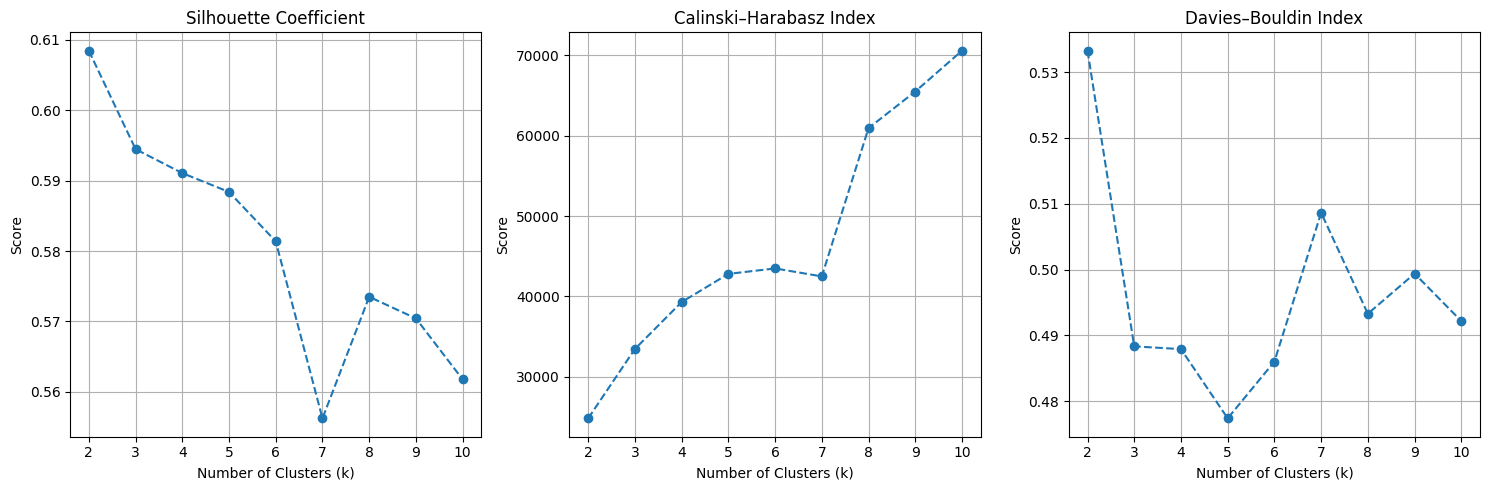

In [38]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt

# Define the range of clusters to evaluate
ks = range(2, 11)

# Initialize lists to store the scores
silhouette_scores = []
calinski_harabasz_scores = []
davies_bouldin_scores = []

# Evaluate clustering for each k
for k in ks:
    km = KMeans(n_clusters=k, random_state=42).fit(X)
    labels = km.labels_
    
    # Compute the metrics
    silhouette_scores.append(silhouette_score(X, labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(X, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X, labels))

# Plot the metrics
plt.figure(figsize=(15, 5))
print("Silhouette Coefficient")
print(np.mean(silhouette_scores))
# Silhouette Coefficient
plt.subplot(1, 3, 1)
plt.plot(ks, silhouette_scores, marker='o', linestyle='--')
plt.title("Silhouette Coefficient")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.grid(True)
print("Calinski–Harabasz Index")
print(np.mean(calinski_harabasz_scores))
# Calinski–Harabasz Index
plt.subplot(1, 3, 2)
plt.plot(ks, calinski_harabasz_scores, marker='o', linestyle='--')
plt.title("Calinski–Harabasz Index")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.grid(True)
print("Davies–Bouldin Index")
print(np.mean(davies_bouldin_scores))
plt.subplot(1, 3, 3)
plt.plot(ks, davies_bouldin_scores, marker='o', linestyle='--')
plt.title("Davies–Bouldin Index")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.grid(True)

plt.tight_layout()
plt.show()

### Fit et Plot KMeans

In [39]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import plotly.graph_objs as go
import plotly.offline as py
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import pandas as pd


def kmeans_fit_and_plot_per_cluster(k, X_final, df):
    df_tmp = df.copy()
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(X_final)
    df_tmp["segment"] = clusters

    # --- Silhouette Analysis ---
    print("Silhouette Analysis...")
    silhouette_avg = silhouette_score(X_final, clusters)
    print(f"For n_clusters = {k}, the average silhouette_score is: {silhouette_avg}")

    sample_silhouette_values = silhouette_samples(X_final, clusters)

    # Print silhouette score for each cluster
    for cluster in range(k):
        cluster_silhouette_avg = sample_silhouette_values[clusters == cluster].mean()
        print(f"Silhouette score for Cluster {cluster}: {cluster_silhouette_avg}")

    # Define consistent colors for clusters
    colormap = plt.colormaps.get_cmap("tab10")
    cluster_colors = [mcolors.to_hex(colormap(i)) for i in range(k)]
    cluster_color_map = {i: cluster_colors[i] for i in range(k)}  # Map cluster index to color

    # --- Silhouette Plot ---
    plt.figure(figsize=(10, 8))
    y_lower = 10
    for i in range(k):
        ith_cluster_silhouette_values = sample_silhouette_values[clusters == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cluster_color_map[i]
        plt.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    plt.title(f"Silhouette analysis for KMeans clustering on sample data with n_clusters = {k}")
    plt.xlabel("The silhouette coefficient values")
    plt.ylabel("Cluster label")
    plt.axvline(x=silhouette_avg, color="red", linestyle="--")
    plt.yticks([])
    plt.xticks(np.arange(-0.1, 1.1, 0.1))
    plt.show()

    # --- PCA Scatter Plot (2D) ---
    print("Visualisation du clustering (2D)...")
    pca = PCA(n_components=2)
    X_pca_2d = pca.fit_transform(X_final)

    plt.figure(figsize=(10, 8))
    for i in range(k):
        cluster_points = X_pca_2d[clusters == i]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], c=cluster_color_map[i], label=f"Cluster {i}", s=10)

    plt.title(f"Visualisation des clusters utilisateurs (PCA 2D)- K = {k}")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- PCA Scatter Plot (3D) ---
    print("Visualisation du clustering (3D)...")
    pca_3d = PCA(n_components=3)
    X_pca_3d = pca_3d.fit_transform(X_final)

    # Prepare data for Plotly
    traces = []
    for i in range(k):
        cluster_points = X_pca_3d[clusters == i]
        trace = go.Scatter3d(
            x=cluster_points[:, 0],
            y=cluster_points[:, 1],
            z=cluster_points[:, 2],
            mode='markers',
            marker=dict(
                size=8,
                color=cluster_color_map[i],  # Use consistent cluster color
                opacity=0.8
            ),
            name=f"Cluster {i}"
        )
        traces.append(trace)

    layout = go.Layout(
        margin=dict(l=0, r=0, b=0, t=0),
        title="Interactive 3D Plot of Clusters"
    )
    fig = go.Figure(data=traces, layout=layout)
    py.iplot(fig, filename='3d-scatter-colorscale')

    return df_tmp

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_cluster_stats(df, segment_column="segment"):
    """
    Plots statistics, distributions, and boxplots for clusters in the DataFrame.

    Parameters:
    - df: DataFrame containing the clustering results and features.
    - segment_column: Name of the column containing cluster segments.

    Returns:
    - stats: A dictionary containing descriptive statistics for each cluster.
    """
    # Ensure the segment column exists
    if segment_column not in df.columns:
        raise ValueError(f"Column '{segment_column}' not found in the DataFrame.")

    # Number of individuals per cluster
    cluster_counts = df[segment_column].value_counts().sort_index()
    print("Number of individuals per cluster:")
    print(cluster_counts)

    # Plot the distribution of individuals per cluster
    plt.figure(figsize=(10, 6))
    cluster_counts.plot(kind="bar", color="skyblue", alpha=0.8)
    plt.title("Distribution of Individuals per Cluster")
    plt.xlabel("Cluster")
    plt.ylabel("Number of Individuals")
    plt.xticks(rotation=0)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

    # Descriptive statistics for each cluster
    stats = {}
    for cluster in cluster_counts.index:
        cluster_data = df[df[segment_column] == cluster]
        cluster_stats = cluster_data.describe()
        stats[cluster] = cluster_stats
        print(f"\nDescriptive statistics for Cluster {cluster}:")
        print(cluster_stats)

    # Boxplots for each column grouped by cluster
    numeric_columns = df.select_dtypes(include=["number"]).columns
    numeric_columns = [col for col in numeric_columns if col != segment_column]

    for col in numeric_columns:
        plt.figure(figsize=(12, 6))
        sns.boxplot(x=segment_column, y=col, data=df, palette="Set3")
        plt.title(f"Boxplot of {col} by Cluster")
        plt.xlabel("Cluster")
        plt.ylabel(col)
        plt.grid(axis="y", linestyle="--", alpha=0.7)
        plt.show()

    return stats

Silhouette Analysis...
For n_clusters = 4, the average silhouette_score is: 0.5910586747832598
Silhouette score for Cluster 0: 0.5079407979019839
Silhouette score for Cluster 1: 0.6180160658952549
Silhouette score for Cluster 2: 0.6957700772245132
Silhouette score for Cluster 3: 0.5445238232167084


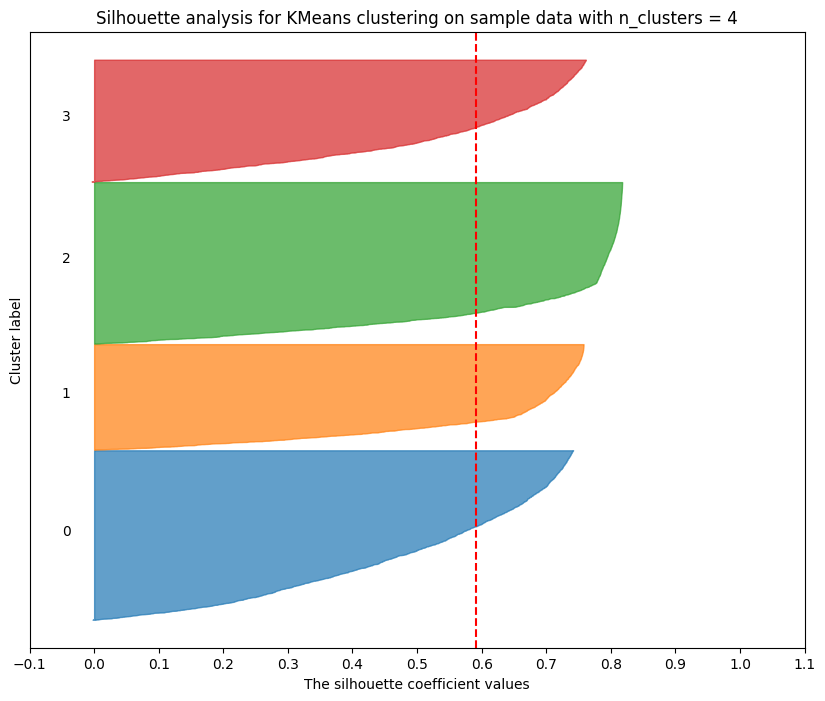

Visualisation du clustering (2D)...


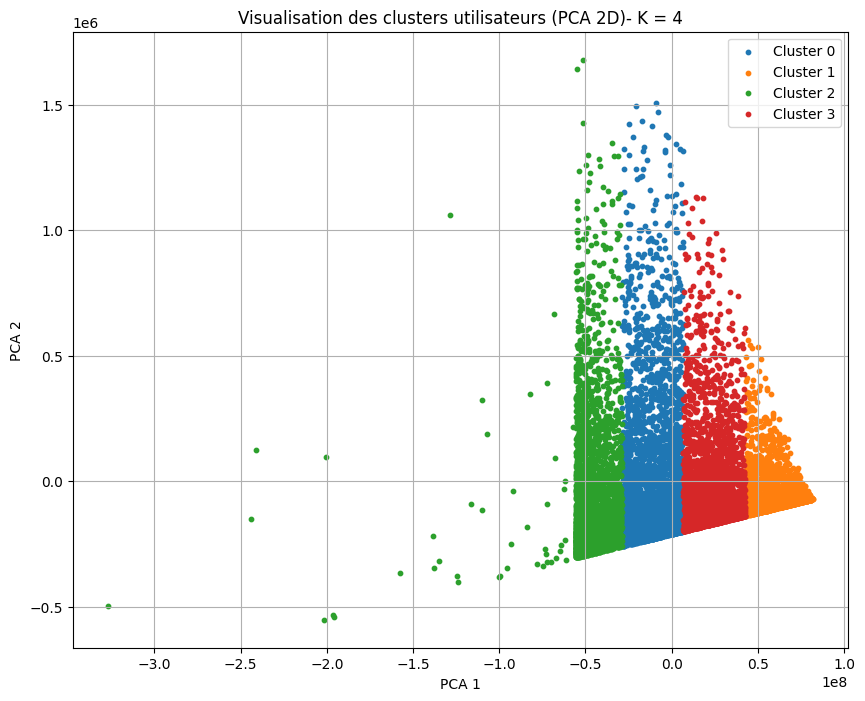

Visualisation du clustering (3D)...


In [41]:
N_CLUSTERS = 4

df_kmeans = kmeans_fit_and_plot_per_cluster(N_CLUSTERS, X, user_segments_df)

In [43]:
# Fermeture de la connexion DuckDB
con.close()